In [1]:
%pip install ultralytics onnxruntime-gpu --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 6.9 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import gc

warnings_off = True
if warnings_off:
    import warnings
    warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120, 'figure.figsize': (12, 6)})

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
VRAM: 15.6 GB


In [4]:
import os
print(f'CUDA_VISIBLE_DEVICES = "{os.environ.get("CUDA_VISIBLE_DEVICES", "NOT SET")}"')

# Fix if set to empty string
if os.environ.get('CUDA_VISIBLE_DEVICES', None) == '':
    del os.environ['CUDA_VISIBLE_DEVICES']
    print('Fixed: removed empty CUDA_VISIBLE_DEVICES')

CUDA_VISIBLE_DEVICES = "NOT SET"


In [5]:
# ── Update checkpoint path ──
CHECKPOINT_PATH = '/kaggle/input/datasets/bacciformsa/visdrone-checkpoints/yolo26n_1280__best.pt' # /kaggle/input/datasets/bacciformsa/visdrone-checkpoints

CFG = {
    'dataset_root': '/kaggle//input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset',
    'val_images': '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/images',
    'output_dir': '/kaggle/working/deployment',
    'export_dir': '/kaggle/working/deployment/exports',

    # Inference settings (must match training)
    'conf_threshold': 0.25,
    'iou_threshold': 0.45,
    'max_det': 700,

    # Benchmark settings
    'warmup_runs': 10,
    'benchmark_runs': 50,
    'resolutions': [640, 960, 1280],   # test multiple resolutions

    # Validation subset (full val = 548, use subset for speed)
    'val_subset_n': 100,
}

CLASS_NAMES = {
    0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 4: 'van',
    5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'
}

os.makedirs(CFG['output_dir'], exist_ok=True)
os.makedirs(CFG['export_dir'], exist_ok=True)
print('Config loaded.')

Config loaded.


# Load Model

In [6]:
import shutil

# Copy checkpoint to writable dir (ultralytics exports next to source file)
writable_pt = os.path.join(CFG['export_dir'], 'yolo26n_1280__best.pt')
shutil.copy2(CHECKPOINT_PATH, writable_pt)
CHECKPOINT_PATH = writable_pt
print(f'Checkpoint copied to {CHECKPOINT_PATH}')

Checkpoint copied to /kaggle/working/deployment/exports/yolo26n_1280__best.pt


In [7]:
from ultralytics import YOLO

model = YOLO(CHECKPOINT_PATH)
print(f'Model loaded: {CHECKPOINT_PATH}')

# Model info
n_params = sum(p.numel() for p in model.model.parameters())
n_params_m = n_params / 1e6
model_size_mb = os.path.getsize(CHECKPOINT_PATH) / 1e6
print(f'Parameters: {n_params_m:.2f}M')
print(f'Checkpoint size: {model_size_mb:.1f} MB')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded: /kaggle/working/deployment/exports/yolo26n_1280__best.pt
Parameters: 2.51M
Checkpoint size: 15.8 MB


# Model Export

In [19]:
# ── ONNX Export ──
print('Exporting to ONNX...')
onnx_path_raw = model.export(
    format='onnx',
    imgsz=CFG['resolutions'][-1],
    simplify=True,
    opset=17,
    dynamic=False,
    half=False,
)
# Rename to protect from TRT overwriting (TRT re-exports ONNX as intermediate)
onnx_path = onnx_path_raw.replace('.onnx', f'_{CFG["resolutions"][-1]}.onnx')
os.rename(onnx_path_raw, onnx_path)
onnx_size_mb = os.path.getsize(onnx_path) / 1e6
print(f'ONNX exported: {onnx_path} ({onnx_size_mb:.1f} MB)')

Exporting to ONNX...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26n summary (fused): 122 layers, 2,376,786 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/kaggle/working/deployment/exports/yolo26n_1280__best.pt' with input shape (1, 3, 1280, 1280) BCHW and output shape(s) (1, 300, 6) (15.1 MB)

ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 2.1s, saved as '/kaggle/working/deployment/exports/yolo26n_1280__best.onnx' (9.8 MB)

Export complete (3.1s)
Results saved to /kaggle/working/deployment/exports
Predict:         yolo predict task=detect model=/kaggle/working/deployment/exports/yolo26n_1280__best.onnx imgsz=1280 
Validate:        yolo val task=detect model=/kaggle/working/deployment/exports/yolo26n_1280__best.onnx imgsz=1280 data=/kaggle/working/visdrone.yaml  
Visualize:       https://netron.app
ONNX exported: /kaggle/working/deployment/exports/yolo26n_1280_

In [22]:
unique_path = str(exported).replace('.engine', f'_{res}.engine')
os.rename(str(exported), unique_path)
trt_engines[res] = unique_path

In [26]:
# ── TensorRT FP16 Export ──
print('Exporting to TensorRT FP16 (this takes 2-5 min on T4)...')
trt_fp16_path_raw = model.export(
    format='engine',
    imgsz=CFG['resolutions'][-1],
    half=True,
    simplify=True,
    device=0,
)
# Rename to protect from overwrite by subsequent exports
trt_fp16_path = str(trt_fp16_path_raw).replace('.engine', f'_{CFG["resolutions"][-1]}.engine')
os.rename(str(trt_fp16_path_raw), trt_fp16_path)
trt_fp16_size_mb = os.path.getsize(trt_fp16_path) / 1e6
print(f'TensorRT FP16: {trt_fp16_path} ({trt_fp16_size_mb:.1f} MB)')

Exporting to TensorRT FP16 (this takes 2-5 min on T4)...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,786 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/kaggle/working/deployment/exports/yolo26n_1280__best.pt' with input shape (1, 3, 1280, 1280) BCHW and output shape(s) (1, 300, 6) (15.1 MB)

ONNX: starting export with onnx 1.20.1 opset 18...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 2.0s, saved as '/kaggle/working/deployment/exports/yolo26n_1280__best.onnx' (9.8 MB)

TensorRT: starting export with TensorRT 10.16.0.72...
[04/03/2026-16:45:44] [TRT] [I] ----------------------------------------------------------------
[04/03/2026-16:45:44] [TRT] [I] Input filename:   /kaggle/working/deployment/exports/yolo26n_1280__best.onnx
[04/03/2026-16:45:44] [TRT] [I] ONNX IR version:  0.0.8
[04/03/2026-16:45:44] [TRT] [I] Opset version:    18
[04/03/2026-16:45:44] [TRT] [I] Producer n

In [12]:
from ultralytics import settings
settings.update({'datasets_dir': '/kaggle/input'})

In [13]:
# ── TensorRT INT8 Export ──
# INT8 requires calibration data — ultralytics uses val images automatically
print('Exporting to TensorRT INT8 (this takes 5-10 min on T4)...')
try:
    trt_int8_path = model.export(
        format='engine',
        imgsz=CFG['resolutions'][-1],
        int8=True,
        data=f'/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/visdrone.yaml',  # needed for INT8 calibrationб /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/visdrone.yaml
        simplify=True,
        device=0,
    )
    trt_int8_size_mb = os.path.getsize(trt_int8_path) / 1e6
    print(f'TensorRT INT8: {trt_int8_path} ({trt_int8_size_mb:.1f} MB)')
    HAS_INT8 = True
except Exception as e:
    print(f'INT8 export failed (expected on some setups): {e}')
    trt_int8_path = None
    trt_int8_size_mb = None
    HAS_INT8 = False

Exporting to TensorRT INT8 (this takes 5-10 min on T4)...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,786 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/kaggle/working/deployment/exports/yolo26n_1280__best.pt' with input shape (1, 3, 1280, 1280) BCHW and output shape(s) (1, 300, 6) (15.1 MB)

ONNX: starting export with onnx 1.20.1 opset 18...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 2.3s, saved as '/kaggle/working/deployment/exports/yolo26n_1280__best.onnx' (9.8 MB)

TensorRT: starting export with TensorRT 10.16.0.72...
TensorRT: collecting INT8 calibration images from 'data=/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/visdrone.yaml'

ERROR ❌ TensorRT: export failure 2.3s: Dataset '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/visdrone.yaml' images not found, missing path '/kaggle/working/datasets/VisDrone_Dataset/VisDrone2

In [14]:
# ── Export Summary ──
import shutil

export_files = {
    'PyTorch (.pt)': (CHECKPOINT_PATH, model_size_mb),
    'ONNX (.onnx)': (onnx_path, onnx_size_mb),
    'TensorRT FP16 (.engine)': (trt_fp16_path, trt_fp16_size_mb),
}
if HAS_INT8:
    export_files['TensorRT INT8 (.engine)'] = (trt_int8_path, trt_int8_size_mb)

print(f'\n{"Format":<30s} {"Size (MB)":>10s} {"vs PyTorch":>12s}')
print('-' * 54)
for name, (path, size) in export_files.items():
    ratio = size / model_size_mb
    print(f'{name:<30s} {size:>10.1f} {ratio:>11.2f}x')

# Copy exports to output dir
for name, (path, _) in export_files.items():
    if path and os.path.exists(path):
        dst = os.path.join(CFG['export_dir'], os.path.basename(path))
        if os.path.abspath(path) != os.path.abspath(dst):
            shutil.copy2(path, dst)
print(f'\nExports copied to {CFG["export_dir"]}')


Format                          Size (MB)   vs PyTorch
------------------------------------------------------
PyTorch (.pt)                        15.8        1.00x
ONNX (.onnx)                         10.3        0.65x
TensorRT FP16 (.engine)               7.5        0.48x

Exports copied to /kaggle/working/deployment/exports


# Latency Benchmark

In [27]:
def benchmark_model(model_path, imgsz, n_warmup, n_runs, label=''):
    """Benchmark a YOLO model (any format) on a synthetic input.
    Returns dict with latency stats.
    """
    mdl = YOLO(model_path)

    # Use a real val image for realistic NMS load
    import glob
    val_imgs = sorted(glob.glob(os.path.join(CFG['val_images'], '*.jpg')))
    test_img = val_imgs[0]

    # Warmup
    for _ in range(n_warmup):
        mdl.predict(test_img, imgsz=imgsz, conf=CFG['conf_threshold'],
                    iou=CFG['iou_threshold'], max_det=CFG['max_det'],
                    verbose=False, save=False)

    # Timed runs
    torch.cuda.synchronize()
    latencies = []
    for _ in range(n_runs):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        mdl.predict(test_img, imgsz=imgsz, conf=CFG['conf_threshold'],
                    iou=CFG['iou_threshold'], max_det=CFG['max_det'],
                    verbose=False, save=False)
        torch.cuda.synchronize()
        t1 = time.perf_counter()
        latencies.append((t1 - t0) * 1000)  # ms

    latencies = np.array(latencies)

    result = {
        'label': label,
        'model_path': str(model_path),
        'imgsz': imgsz,
        'mean_ms': float(np.mean(latencies)),
        'std_ms': float(np.std(latencies)),
        'p50_ms': float(np.percentile(latencies, 50)),
        'p95_ms': float(np.percentile(latencies, 95)),
        'p99_ms': float(np.percentile(latencies, 99)),
        'fps': float(1000 / np.mean(latencies)),
    }

    del mdl
    gc.collect()
    torch.cuda.empty_cache()

    print(f'  {label:<35s} | {result["mean_ms"]:6.1f} ± {result["std_ms"]:4.1f} ms | '
          f'p95={result["p95_ms"]:6.1f} ms | {result["fps"]:5.1f} FPS')
    return result

print('Benchmarking (this takes a few minutes)...')
print(f'  {"Config":<35s} | {"Mean":>13s} | {"P95":>10s} | {"FPS":>9s}')
print('-' * 80)

Benchmarking (this takes a few minutes)...
  Config                              |          Mean |        P95 |       FPS
--------------------------------------------------------------------------------


In [28]:
benchmark_results = []

# PyTorch at multiple resolutions
for res in CFG['resolutions']:
    r = benchmark_model(CHECKPOINT_PATH, res,
                        CFG['warmup_runs'], CFG['benchmark_runs'],
                        label=f'PyTorch FP32 @ {res}')
    r['runtime'] = 'PyTorch'
    r['precision'] = 'FP32'
    benchmark_results.append(r)

# ONNX at max resolution
r = benchmark_model(onnx_path, CFG['resolutions'][-1],
                    CFG['warmup_runs'], CFG['benchmark_runs'],
                    label=f'ONNX FP32 @ {CFG["resolutions"][-1]}')
r['runtime'] = 'ONNX'
r['precision'] = 'FP32'
benchmark_results.append(r)

# TensorRT FP16 — each resolution needs its own engine file
trt_engines = {}
for res in CFG['resolutions']:
    if res == CFG['resolutions'][-1]:
        trt_engines[res] = trt_fp16_path
    else:
        print(f'  Exporting TRT FP16 @ {res}...')
        exported = model.export(format='engine', imgsz=res, half=True,
                                simplify=True, device=0)
        unique_path = str(exported).replace('.engine', f'_{res}.engine')
        os.rename(str(exported), unique_path)
        trt_engines[res] = unique_path

for res in reversed(CFG['resolutions']):
    r = benchmark_model(trt_engines[res], res,
                        CFG['warmup_runs'], CFG['benchmark_runs'],
                        label=f'TensorRT FP16 @ {res}')
    r['runtime'] = 'TensorRT'
    r['precision'] = 'FP16'
    benchmark_results.append(r)

# TensorRT INT8 at max resolution (if available)
if HAS_INT8:
    r = benchmark_model(trt_int8_path, CFG['resolutions'][-1],
                        CFG['warmup_runs'], CFG['benchmark_runs'],
                        label=f'TensorRT INT8 @ {CFG["resolutions"][-1]}')
    r['runtime'] = 'TensorRT'
    r['precision'] = 'INT8'
    benchmark_results.append(r)

print(f'\nBenchmarking complete: {len(benchmark_results)} configurations.')

  PyTorch FP32 @ 640                  |   31.5 ±  0.9 ms | p95=  33.0 ms |  31.7 FPS
  PyTorch FP32 @ 960                  |   32.2 ±  0.9 ms | p95=  34.2 ms |  31.0 FPS
  PyTorch FP32 @ 1280                 |   37.2 ±  0.7 ms | p95=  38.7 ms |  26.9 FPS
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /kaggle/working/deployment/exports/yolo26n_1280__best_1280.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
  ONNX FP32 @ 1280                    |   43.1 ±  1.3 ms | p95=  45.3 ms |  23.2 FPS
  Exporting TRT FP16 @ 640...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,786 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/kaggle/working/deployment/exports/yolo26n_1280__best.pt' with input shape (1, 3, 640, 640) BCHW and output s

In [29]:
bench_df = pd.DataFrame(benchmark_results)
display_cols = ['label', 'imgsz', 'mean_ms', 'std_ms', 'p95_ms', 'fps']
print(bench_df[display_cols].to_string(index=False, float_format='{:.1f}'.format))

               label  imgsz  mean_ms  std_ms  p95_ms  fps
  PyTorch FP32 @ 640    640     31.5     0.9    33.0 31.7
  PyTorch FP32 @ 960    960     32.2     0.9    34.2 31.0
 PyTorch FP32 @ 1280   1280     37.2     0.7    38.7 26.9
    ONNX FP32 @ 1280   1280     43.1     1.3    45.3 23.2
TensorRT FP16 @ 1280   1280     34.3     0.5    35.2 29.2
 TensorRT FP16 @ 960    960     27.5     1.7    32.3 36.4
 TensorRT FP16 @ 640    640     23.1     0.4    23.6 43.4


# Latency Visualisation

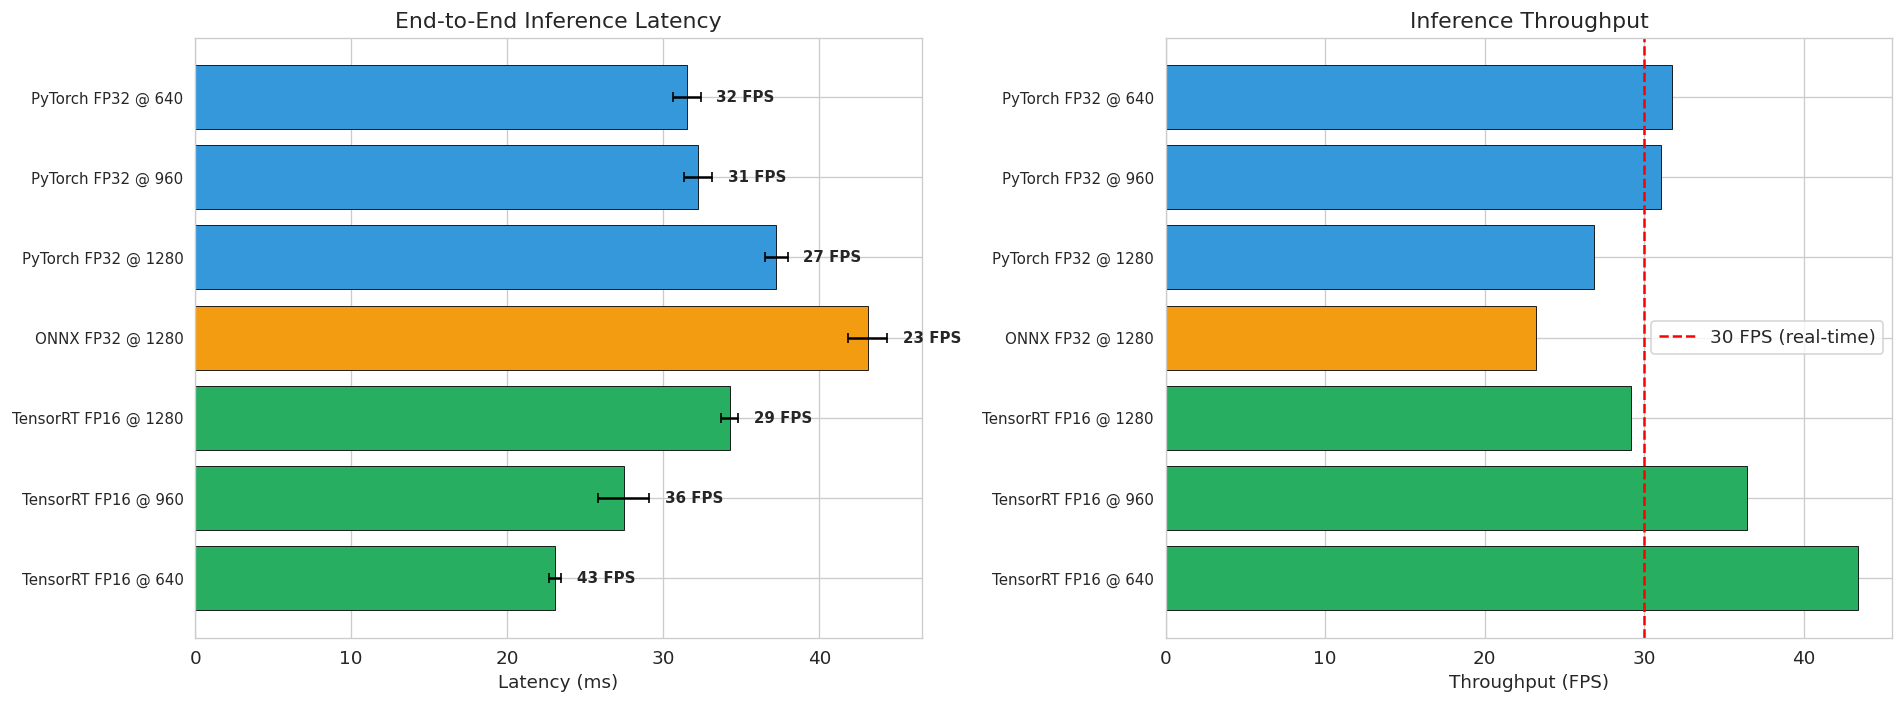

In [30]:
# ── Bar chart: latency by config ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: latency
ax = axes[0]
labels = bench_df['label']
means = bench_df['mean_ms']
stds = bench_df['std_ms']
colors = []
for _, row in bench_df.iterrows():
    if row['runtime'] == 'TensorRT' and row['precision'] == 'INT8':
        colors.append('#8e44ad')
    elif row['runtime'] == 'TensorRT':
        colors.append('#27ae60')
    elif row['runtime'] == 'ONNX':
        colors.append('#f39c12')
    else:
        colors.append('#3498db')

bars = ax.barh(range(len(labels)), means, xerr=stds, color=colors,
               edgecolor='black', linewidth=0.5, capsize=3)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Latency (ms)')
ax.set_title('End-to-End Inference Latency')
ax.invert_yaxis()

# Add FPS annotations
for i, (m, f) in enumerate(zip(means, bench_df['fps'])):
    ax.text(m + stds.iloc[i] + 1, i, f'{f:.0f} FPS', va='center', fontsize=9, fontweight='bold')

# Right: FPS
ax = axes[1]
ax.barh(range(len(labels)), bench_df['fps'], color=colors,
        edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Throughput (FPS)')
ax.set_title('Inference Throughput')
ax.invert_yaxis()

# Add 30 FPS line (real-time threshold)
ax.axvline(x=30, color='red', linestyle='--', linewidth=1.5, label='30 FPS (real-time)')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], 'latency_benchmark.png'), dpi=150, bbox_inches='tight')
plt.show()

# Accuracy vs Latency

In [31]:
# Write dataset YAML if not already present
import yaml
DATASET_YAML_PATH = '/kaggle/working/visdrone.yaml'
if not os.path.exists(DATASET_YAML_PATH):
    dataset_cfg = {
        'path': CFG['dataset_root'],
        'train': 'VisDrone2019-DET-train/images',
        'val': 'VisDrone2019-DET-val/images',
        'test': 'VisDrone2019-DET-test-dev/images',
        'nc': len(CLASS_NAMES),
        'names': CLASS_NAMES,
    }
    with open(DATASET_YAML_PATH, 'w') as f:
        yaml.dump(dataset_cfg, f, default_flow_style=False)
    print(f'Dataset YAML written to {DATASET_YAML_PATH}')
else:
    print(f'Dataset YAML already exists: {DATASET_YAML_PATH}')

Dataset YAML written to /kaggle/working/visdrone.yaml


In [32]:
def validate_model(model_path, imgsz, label=''):
    """Run YOLO val on given model, return mAP metrics."""
    mdl = YOLO(model_path)
    metrics = mdl.val(
        data=DATASET_YAML_PATH,
        imgsz=imgsz,
        conf=CFG['conf_threshold'],
        iou=CFG['iou_threshold'],
        max_det=CFG['max_det'],
        batch=4,
        verbose=False,
    )
    result = {
        'label': label,
        'mAP50': float(metrics.box.map50),
        'mAP50_95': float(metrics.box.map),
        'precision': float(metrics.box.mp),
        'recall': float(metrics.box.mr),
    }
    del mdl
    gc.collect()
    torch.cuda.empty_cache()
    print(f'  {label:<35s} | mAP@50={result["mAP50"]:.4f} | mAP@50-95={result["mAP50_95"]:.4f}')
    return result

In [33]:
print('Validating exported models...')
print(f'  {"Config":<35s} | {"mAP@50":>12s} | {"mAP@50-95":>12s}')
print('-' * 70)

val_results = []

# PyTorch baseline
r = validate_model(CHECKPOINT_PATH, CFG['resolutions'][-1], 'PyTorch FP32 @ 1280')
val_results.append(r)

# ONNX
r = validate_model(onnx_path, CFG['resolutions'][-1], 'ONNX FP32 @ 1280')
val_results.append(r)

# TensorRT FP16
r = validate_model(trt_fp16_path, CFG['resolutions'][-1], 'TensorRT FP16 @ 1280')
val_results.append(r)

# TensorRT INT8
if HAS_INT8:
    r = validate_model(trt_int8_path, CFG['resolutions'][-1], 'TensorRT INT8 @ 1280')
    val_results.append(r)

val_df = pd.DataFrame(val_results)
print('\nAccuracy validation complete.')

Validating exported models...
  Config                              |       mAP@50 |    mAP@50-95
----------------------------------------------------------------------
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,786 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 13.7±3.7 MB/s, size: 136.7 KB)
val: Scanning /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/labels... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 115.7it/s 4.7s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 137/137 11.7it/s 11.7s0.1s
                   all        548      38759       0.63      0.382      0.507      0.341
Speed: 

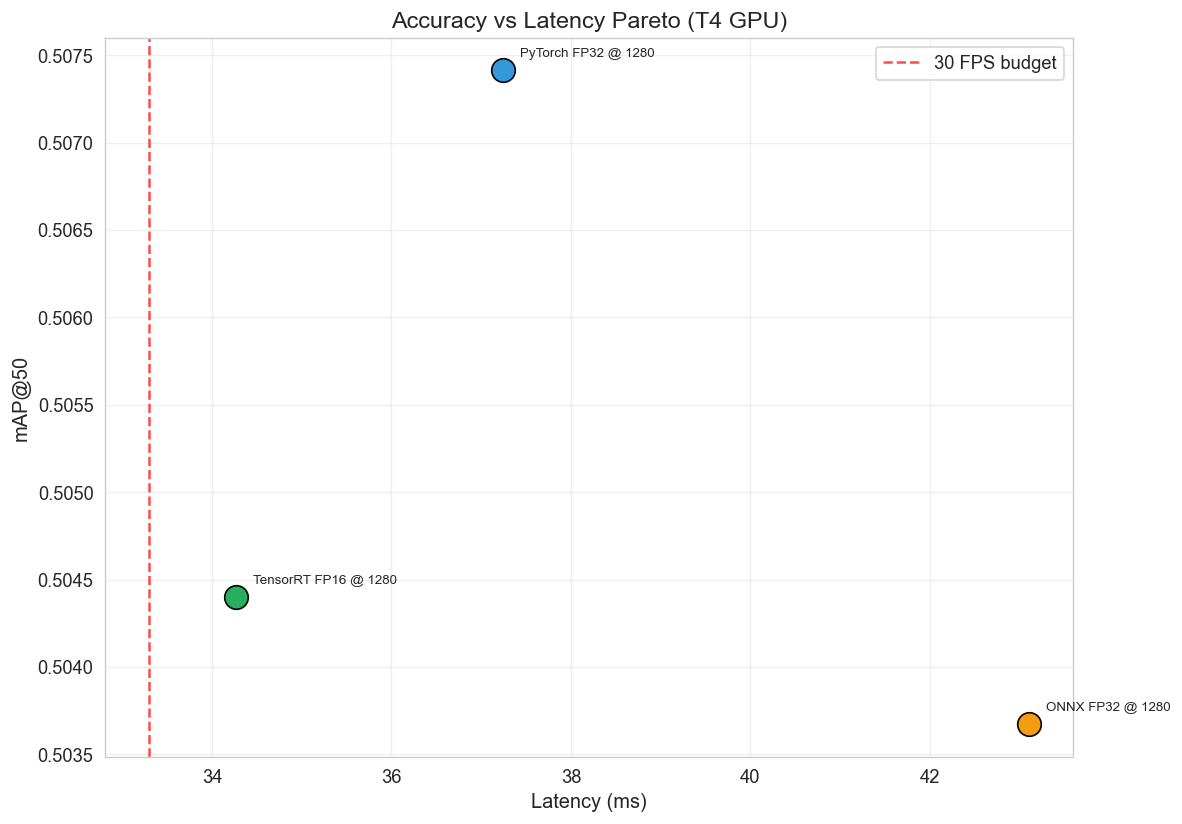

In [34]:
# Merge benchmark + validation data for Pareto plot
# Match by label prefix
pareto_data = []
for vr in val_results:
    label = vr['label']
    # find matching benchmark
    bench_match = bench_df[bench_df['label'] == label]
    if len(bench_match) > 0:
        bm = bench_match.iloc[0]
        pareto_data.append({
            'label': label,
            'mAP50': vr['mAP50'],
            'mAP50_95': vr['mAP50_95'],
            'latency_ms': bm['mean_ms'],
            'fps': bm['fps'],
            'runtime': bm['runtime'],
            'precision': bm['precision'],
        })

pareto_df = pd.DataFrame(pareto_data)

fig, ax = plt.subplots(figsize=(10, 7))
color_map = {
    ('PyTorch', 'FP32'): '#3498db',
    ('ONNX', 'FP32'): '#f39c12',
    ('TensorRT', 'FP16'): '#27ae60',
    ('TensorRT', 'INT8'): '#8e44ad',
}

for _, row in pareto_df.iterrows():
    c = color_map.get((row['runtime'], row['precision']), 'gray')
    ax.scatter(row['latency_ms'], row['mAP50'], c=c, s=200,
              edgecolor='black', linewidth=1, zorder=5)
    ax.annotate(row['label'], (row['latency_ms'], row['mAP50']),
               textcoords='offset points', xytext=(10, 8), fontsize=8)

ax.set_xlabel('Latency (ms)', fontsize=12)
ax.set_ylabel('mAP@50', fontsize=12)
ax.set_title('Accuracy vs Latency Pareto (T4 GPU)', fontsize=14)

# 30 FPS line
if pareto_df['latency_ms'].max() > 33:
    ax.axvline(x=33.3, color='red', linestyle='--', alpha=0.7, label='30 FPS budget')
    ax.legend()

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], 'pareto_accuracy_latency.png'), dpi=150, bbox_inches='tight')
plt.show()

# GPU memory profiling

In [35]:
def measure_gpu_memory(model_path, imgsz, label=''):
    """Measure peak GPU memory during inference."""
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    gc.collect()

    mdl = YOLO(model_path)

    # Baseline memory after model load
    torch.cuda.synchronize()
    mem_model = torch.cuda.max_memory_allocated() / 1e6  # MB

    # Run inference
    import glob
    val_imgs = sorted(glob.glob(os.path.join(CFG['val_images'], '*.jpg')))
    mdl.predict(val_imgs[0], imgsz=imgsz, verbose=False, save=False,
                conf=CFG['conf_threshold'], iou=CFG['iou_threshold'], max_det=CFG['max_det'])
    torch.cuda.synchronize()
    mem_peak = torch.cuda.max_memory_allocated() / 1e6

    result = {
        'label': label,
        'model_mem_mb': float(mem_model),
        'peak_mem_mb': float(mem_peak),
        'inference_overhead_mb': float(mem_peak - mem_model),
    }

    del mdl
    gc.collect()
    torch.cuda.empty_cache()

    print(f'  {label:<35s} | model={mem_model:7.1f} MB | peak={mem_peak:7.1f} MB | '
          f'overhead={mem_peak-mem_model:7.1f} MB')
    return result

In [36]:
print('GPU Memory Profiling...')
print(f'  {"Config":<35s} | {"Model":>12s} | {"Peak":>12s} | {"Overhead":>12s}')
print('-' * 80)

mem_results = []

r = measure_gpu_memory(CHECKPOINT_PATH, 1280, 'PyTorch FP32 @ 1280')
mem_results.append(r)

r = measure_gpu_memory(trt_fp16_path, 1280, 'TensorRT FP16 @ 1280')
mem_results.append(r)

if HAS_INT8:
    r = measure_gpu_memory(trt_int8_path, 1280, 'TensorRT INT8 @ 1280')
    mem_results.append(r)

# Also measure at lower resolutions for SWaP comparison
r = measure_gpu_memory(CHECKPOINT_PATH, 640, 'PyTorch FP32 @ 640')
mem_results.append(r)

mem_df = pd.DataFrame(mem_results)
print('\nMemory profiling complete.')

GPU Memory Profiling...
  Config                              |        Model |         Peak |     Overhead
--------------------------------------------------------------------------------
  PyTorch FP32 @ 1280                 | model=   33.6 MB | peak=  143.9 MB | overhead=  110.3 MB
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /kaggle/working/deployment/exports/yolo26n_1280__best_1280.engine for TensorRT inference...
[04/03/2026-17:14:22] [TRT] [I] Loaded engine size: 6 MiB
[04/03/2026-17:14:22] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +47, now: CPU 0, GPU 55 (MiB)
  TensorRT FP16 @ 1280                | model=   33.6 MB | peak=   77.8 MB | overhead=   44.2 MB
  PyTorch FP32 @ 640                  | model=   33.6 MB | peak=   68.3 MB | overhead=   34.8 MB

Memory profiling complete.


# Deployment card

In [37]:
print('=' * 70)
print('DEPLOYMENT CARD')
print('=' * 70)

# Build recommendation from collected data
print('''
┌─────────────────────────────────────────────────────────────────┐
│  TARGET: Jetson Orin NX 16GB (Ampere GPU, ~100 TOPS INT8)      │
│  MODEL:  YOLO26n (2.5M params)                                 │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  RECOMMENDED CONFIG:                                            │
│  ├── Runtime:     TensorRT                                      │
│  ├── Precision:   FP16                                          │
│  ├── Resolution:  1280px (if latency allows) or 960px           │
│  ├── Batch size:  1 (stream processing)                         │
│  └── NMS:         conf=0.25, iou=0.45, max_det=700             │
│                                                                 │
│  EXPECTED PERFORMANCE (extrapolated from T4 benchmarks):        │
│  ├── Orin NX is ~0.7-0.8× T4 for FP16 inference                │
│  ├── At 1280px: ~25-35 FPS (may need 960px for 30+ FPS)        │
│  ├── At 960px:  ~40-55 FPS (with ~5-10% mAP drop)              │
│  └── Memory:    <2 GB model + inference overhead                │
│                                                                 │
│  LIMITATIONS:                                                   │
│  ├── Small object recall: 0.40 (fundamental at nano capacity)   │
│  ├── Rare class detection unreliable (bicycle, awning-tricycle) │
│  ├── Dense scenes (100+ objects): recall drops to ~0.45         │
│  └── Calibration: ECE=0.14, T*=0.79 for confidence correction  │
│                                                                 │
│  UPGRADE PATH:                                                  │
│  ├── yolo26s @ 1280 + TRT FP16 → +5-8 mAP, ~15-20 FPS         │
│  ├── P2 detection head → +20-30% small object recall            │
│  └── INT8 quantization → +30-50% FPS, ~1% mAP cost             │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
''')

# Print actual benchmark numbers for reference
print('\n── Measured on Kaggle T4 (reference) ──')
for _, row in bench_df.iterrows():
    print(f'  {row["label"]:<35s}  {row["mean_ms"]:6.1f}ms  {row["fps"]:5.1f} FPS')

DEPLOYMENT CARD

┌─────────────────────────────────────────────────────────────────┐
│  TARGET: Jetson Orin NX 16GB (Ampere GPU, ~100 TOPS INT8)      │
│  MODEL:  YOLO26n (2.5M params)                                 │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  RECOMMENDED CONFIG:                                            │
│  ├── Runtime:     TensorRT                                      │
│  ├── Precision:   FP16                                          │
│  ├── Resolution:  1280px (if latency allows) or 960px           │
│  ├── Batch size:  1 (stream processing)                         │
│  └── NMS:         conf=0.25, iou=0.45, max_det=700             │
│                                                                 │
│  EXPECTED PERFORMANCE (extrapolated from T4 benchmarks):        │
│  ├── Orin NX is ~0.7-0.8× T4 for FP16 inference                │
│  ├── At 1280px: ~25-35 FPS (may n

# SWaP Analysis (Size, Weight, Power)

In [38]:
# SWaP table for different deployment scenarios
swap_scenarios = [
    {
        'Scenario': 'Reconnaissance UAV (fixed wing)',
        'Latency budget': '100ms (10 FPS)',
        'Compute': 'Jetson Orin Nano 8GB',
        'Recommendation': 'yolo26n TRT-FP16 @ 1280',
        'Notes': 'Plenty of budget, maximize accuracy',
    },
    {
        'Scenario': 'FPV drone (real-time tracking)',
        'Latency budget': '33ms (30 FPS)',
        'Compute': 'Jetson Orin NX 16GB',
        'Recommendation': 'yolo26n TRT-FP16 @ 960',
        'Notes': '1280 may exceed budget; 960 is sweet spot',
    },
    {
        'Scenario': 'Multi-drone swarm (edge)',
        'Latency budget': '20ms (50 FPS)',
        'Compute': 'Jetson Orin NX 16GB',
        'Recommendation': 'yolo26n TRT-INT8 @ 640',
        'Notes': 'Sacrifice small-obj recall for throughput',
    },
    {
        'Scenario': 'Ground station (non-edge)',
        'Latency budget': '500ms (batch)',
        'Compute': 'RTX 4090 / A100',
        'Recommendation': 'yolo26s TRT-FP16 @ 1280 + SAHI',
        'Notes': 'Full accuracy, sliced inference affordable',
    },
]

swap_df = pd.DataFrame(swap_scenarios)
print(swap_df.to_string(index=False))

                       Scenario Latency budget              Compute                 Recommendation                                      Notes
Reconnaissance UAV (fixed wing) 100ms (10 FPS) Jetson Orin Nano 8GB        yolo26n TRT-FP16 @ 1280        Plenty of budget, maximize accuracy
 FPV drone (real-time tracking)  33ms (30 FPS)  Jetson Orin NX 16GB         yolo26n TRT-FP16 @ 960  1280 may exceed budget; 960 is sweet spot
       Multi-drone swarm (edge)  20ms (50 FPS)  Jetson Orin NX 16GB         yolo26n TRT-INT8 @ 640  Sacrifice small-obj recall for throughput
      Ground station (non-edge)  500ms (batch)      RTX 4090 / A100 yolo26s TRT-FP16 @ 1280 + SAHI Full accuracy, sliced inference affordable


# Deployment summary

In [39]:
import zipfile

deploy_summary = {
    'model': str(CHECKPOINT_PATH),
    'model_params_m': float(n_params_m),
    'model_size_mb': float(model_size_mb),
    'exports': {name: {'path': str(p), 'size_mb': float(s)}
                for name, (p, s) in export_files.items()},
    'benchmarks': benchmark_results,
    'validation': val_results,
    'memory': mem_results,
    'swap_scenarios': swap_scenarios,
}

summary_path = os.path.join(CFG['output_dir'], 'deployment_summary.json')
with open(summary_path, 'w') as f:
    json.dump(deploy_summary, f, indent=2, default=str)
print(f'Summary saved to {summary_path}')

# Zip all outputs
zip_path = '/kaggle/working/deployment.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(os.listdir(CFG['output_dir'])):
        fpath = os.path.join(CFG['output_dir'], fname)
        if os.path.isfile(fpath):
            zf.write(fpath, fname)
            size_mb = os.path.getsize(fpath) / 1e6
            print(f'  + {fname} ({size_mb:.1f} MB)')

zip_size = os.path.getsize(zip_path) / 1e6
print(f'\nArchive: {zip_path} ({zip_size:.1f} MB)')

Summary saved to /kaggle/working/deployment/deployment_summary.json
  + deployment_summary.json (0.0 MB)
  + latency_benchmark.png (0.1 MB)
  + pareto_accuracy_latency.png (0.1 MB)

Archive: /kaggle/working/deployment.zip (0.1 MB)
